# Pitcher Model Hyperparameter Tuning
Optuna-based search for the best `MVTPitcherModel` configuration.
The winning model, scaler, and metadata are saved to `results/pitcher_model/`.

In [1]:
# Configuration Parameters
N_TRIALS = 5            # Optuna trials per model (start small, increase later)
NUM_EPOCHS = 100        # Max epochs per trial (early stopping will cut short)
PATIENCE = 15           # Early stopping patience
DEVICE = 'mps'          # 'mps' for Apple Silicon, 'cpu' for fallback
RESULTS_DIR = './results/pitcher_model/mvt/'
MIN_QUAL_IP = 10

In [2]:
import os
import sys
import json
import pickle

# Find project root (contains src/ and data/) and add to sys.path
_search = os.getcwd()
for _ in range(6):
    if os.path.isdir(os.path.join(_search, 'src')) and os.path.isdir(os.path.join(_search, 'data')):
        if _search not in sys.path:
            sys.path.insert(0, _search)
        os.chdir(_search)
        break
    _search = os.path.dirname(_search)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import optuna

from src.pitchers.mvt_model import MVTPitcherDataset, MVTPitcherModel
from src.pitchers.war_cnn_model import CNNPitcherDataset, CNNPitcherModel

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Load data — verify CSV has pitching columns, re-download if not
csv_path = './data/pitching_stats.csv'
need_download = True
if os.path.exists(csv_path):
    data = pd.read_csv(csv_path)
    if 'IP' in data.columns:
        need_download = False
        print(f'Found {csv_path} with {len(data)} rows.')

if need_download:
    print(f'{csv_path} missing pitching columns — downloading via pybaseball.')
    from pybaseball import pitching_stats
    data = pitching_stats(start_season=2015, end_season=2025, qual=10)
    data.to_csv(csv_path, index=False)
    print(f'Saved {len(data)} rows to {csv_path}.')

/opt/miniconda3/envs/dugout/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found ./data/pitching_stats.csv with 6850 rows.


In [12]:
data.columns.tolist()

['IDfg',
 'Season',
 'Name',
 'Team',
 'Age',
 'W',
 'L',
 'WAR',
 'ERA',
 'G',
 'GS',
 'CG',
 'ShO',
 'SV',
 'BS',
 'IP',
 'TBF',
 'H',
 'R',
 'ER',
 'HR',
 'BB',
 'IBB',
 'HBP',
 'WP',
 'BK',
 'SO',
 'GB',
 'FB',
 'LD',
 'IFFB',
 'Balls',
 'Strikes',
 'Pitches',
 'RS',
 'IFH',
 'BU',
 'BUH',
 'K/9',
 'BB/9',
 'K/BB',
 'H/9',
 'HR/9',
 'AVG',
 'WHIP',
 'BABIP',
 'LOB%',
 'FIP',
 'GB/FB',
 'LD%',
 'GB%',
 'FB%',
 'IFFB%',
 'HR/FB',
 'IFH%',
 'BUH%',
 'Starting',
 'Start-IP',
 'Relieving',
 'Relief-IP',
 'RAR',
 'Dollars',
 'tERA',
 'xFIP',
 'WPA',
 '-WPA',
 '+WPA',
 'RE24',
 'REW',
 'pLI',
 'inLI',
 'gmLI',
 'exLI',
 'Pulls',
 'WPA/LI',
 'Clutch',
 'FB% 2',
 'FBv',
 'SL%',
 'SLv',
 'CT%',
 'CTv',
 'CB%',
 'CBv',
 'CH%',
 'CHv',
 'SF%',
 'SFv',
 'KN%',
 'KNv',
 'XX%',
 'PO%',
 'wFB',
 'wSL',
 'wCT',
 'wCB',
 'wCH',
 'wSF',
 'wKN',
 'wFB/C',
 'wSL/C',
 'wCT/C',
 'wCB/C',
 'wCH/C',
 'wSF/C',
 'wKN/C',
 'O-Swing%',
 'Z-Swing%',
 'Swing%',
 'O-Contact%',
 'Z-Contact%',
 'Contact%',
 'Zone%'

In [ ]:
# Fantasy score map (used for final evaluation, not training loss)
score_map = {
    'IP': 2.49,a
    'ER': -2.75,
    'SO': 0.75,
    # 'QS': 3.0,
    'SV': 2.25,
    'BS': -2.0,
    # 'WP': -0.75,
    # 'B': -1.5,
    'H': -0.75,
    'BB': -0.5,
    'HBP': -0.75,
    'W': 2.0,
    'HLD': 2.25,
    'L': -1.0,
    # 'SO (shutout)': 3.0,
    # 'PKO': 2.0,
}

aux_features = [
    'G', 'GS', 'TBF', 'FIP', 'xFIP','xERA', 'SIERA', 'GB%', 'FB%','SwStr%', 'CStr%','CSW%', 
    'K/9', 'BB/9', 'HR/9', 'K-BB%', 'K/BB',  'GB/FB','Relief-IP', 'Start-IP',
]

features = list(score_map.keys()) + aux_features

device = torch.device(DEVICE if DEVICE == 'mps' and torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [4]:
def prepare_data(X, y_features, features_list, batch_size=32):
    """
    StandardScaler on sequences, per-feature target normalization, 80/20 split.
    Returns loaders, scaler, and feature_stats dict.
    """
    X_np = X.cpu().numpy()
    num_sequences, seq_len, num_features = X_np.shape

    # Scale sequences
    X_reshaped = X_np.reshape(-1, num_features)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_reshaped).reshape(num_sequences, seq_len, num_features)
    X_scaled = torch.tensor(X_scaled, dtype=torch.float32)

    # Per-feature target normalization
    y_np = y_features.cpu().numpy()
    feature_stats = {}
    y_norm = np.zeros_like(y_np)
    for i, name in enumerate(features_list):
        mean = float(np.mean(y_np[:, i]))
        std = float(np.std(y_np[:, i]))
        feature_stats[name] = (mean, std)
        y_norm[:, i] = (y_np[:, i] - mean) / (std + 1e-8)
    y_norm = torch.tensor(y_norm, dtype=torch.float32)

    # 80/20 split
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y_norm, test_size=0.2, random_state=42
    )

    train_loader = DataLoader(
        TensorDataset(X_train.to(device), y_train.to(device)),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val.to(device), y_val.to(device)),
        batch_size=batch_size, shuffle=False
    )

    return train_loader, val_loader, scaler, feature_stats

In [5]:
def train_model(model, train_loader, val_loader, num_epochs=100, lr=1e-3, patience=15):
    """
    Train MVTPitcherModel with MSE loss on all features. Returns best val loss.
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val_loss

In [6]:
# Build dataset once (default nlookbacks=5 for dataset creation;
# the model's nlookbacks param matches whatever the dataset produces)
mvt_dataset = MVTPitcherDataset(
    data=data, features=features, nlookbacks=5, min_qual_ip=MIN_QUAL_IP
)
X = mvt_dataset.sequences
y_features = mvt_dataset.targets_features
print(f'Dataset: {X.shape}')


def objective(trial):
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4, 8])
    if d_model % nhead != 0:
        raise optuna.TrialPruned()

    num_layers = trial.suggest_int('num_layers', 1, 4)
    dim_feedforward = trial.suggest_categorical('dim_feedforward', [64, 128, 256, 512])
    dropout = trial.suggest_float('dropout', 0.05, 0.4)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    nlookbacks = trial.suggest_int('nlookbacks', 3, 8)

    # Rebuild dataset with this nlookbacks
    ds = MVTPitcherDataset(
        data=data, features=features, nlookbacks=nlookbacks, min_qual_ip=MIN_QUAL_IP
    )

    train_loader, val_loader, _, _ = prepare_data(
        ds.sequences, ds.targets_features, features, batch_size=batch_size
    )

    model = MVTPitcherModel(
        input_dim=len(features),
        num_features=len(features),
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        nlookbacks=nlookbacks,
    )

    val_loss = train_model(
        model, train_loader, val_loader,
        num_epochs=NUM_EPOCHS, lr=lr, patience=PATIENCE,
    )
    return val_loss

Dataset: torch.Size([4894, 5, 21])


In [7]:
print('Running hyperparameter search...')
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS)
print(f'Best val loss: {study.best_value:.6f}')

Running hyperparameter search...
Best val loss: 0.656357


In [8]:
print('=== Best Trial ===')
print(f'  Val loss: {study.best_value:.6f}')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

=== Best Trial ===
  Val loss: 0.656357
  d_model: 64
  nhead: 2
  num_layers: 2
  dim_feedforward: 64
  dropout: 0.11634022453190997
  lr: 0.0004403818492559868
  batch_size: 64
  nlookbacks: 5


In [9]:
# Retrain best model from scratch
p = study.best_params
nlookbacks = p['nlookbacks']

best_ds = MVTPitcherDataset(
    data=data, features=features, nlookbacks=nlookbacks, min_qual_ip=MIN_QUAL_IP
)
train_loader, val_loader, scaler, feature_stats = prepare_data(
    best_ds.sequences, best_ds.targets_features, features, batch_size=p['batch_size']
)

best_model = MVTPitcherModel(
    input_dim=len(features),
    num_features=len(features),
    d_model=p['d_model'],
    nhead=p['nhead'],
    num_layers=p['num_layers'],
    dim_feedforward=p['dim_feedforward'],
    dropout=p['dropout'],
    nlookbacks=nlookbacks,
)

train_model(
    best_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=p['lr'], patience=PATIENCE,
)

# Evaluate on validation set — per-feature metrics (denormalized)
best_model.eval()
best_model.to(device)
all_preds, all_actuals = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        preds = best_model(X_batch)
        all_preds.extend(preds.cpu().numpy())
        all_actuals.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_actuals = np.array(all_actuals)

# Denormalize
preds_denorm = np.zeros_like(all_preds)
actuals_denorm = np.zeros_like(all_actuals)
for i, fname in enumerate(features):
    mean, std = feature_stats[fname]
    preds_denorm[:, i] = all_preds[:, i] * std + mean
    actuals_denorm[:, i] = all_actuals[:, i] * std + mean

print('Per-Feature Validation Metrics (denormalized):')
per_feature_metrics = {}
for i, fname in enumerate(features):
    mae = mean_absolute_error(actuals_denorm[:, i], preds_denorm[:, i])
    r2 = r2_score(all_actuals[:, i], all_preds[:, i])
    per_feature_metrics[fname] = {'mae': float(mae), 'r2': float(r2)}
    print(f'  {fname:15s} — MAE: {mae:.4f}, R²: {r2:.4f}')

# Overall MSE across all features (normalized)
overall_mse = mean_squared_error(all_actuals, all_preds)
overall_mae = mean_absolute_error(all_actuals, all_preds)
overall_r2 = r2_score(all_actuals.flatten(), all_preds.flatten())
print(f'\nOverall — MSE: {overall_mse:.4f}, MAE: {overall_mae:.4f}, R²: {overall_r2:.4f}')

Per-Feature Validation Metrics (denormalized):
  IP              — MAE: 30.4510, R²: 0.4206
  ER              — MAE: 13.5058, R²: 0.4242
  SO              — MAE: 30.5644, R²: 0.4186
  SV              — MAE: 2.2736, R²: 0.4776
  BS              — MAE: 0.9554, R²: 0.3520
  WP              — MAE: 1.7516, R²: 0.1723
  H               — MAE: 27.8271, R²: 0.4360
  BB              — MAE: 10.5036, R²: 0.3394
  HBP             — MAE: 1.9613, R²: 0.2352
  W               — MAE: 2.4583, R²: 0.3254
  HLD             — MAE: 3.5894, R²: 0.2799
  L               — MAE: 2.2310, R²: 0.3154
  G               — MAE: 13.3380, R²: 0.3024
  GS              — MAE: 4.9153, R²: 0.5732
  TBF             — MAE: 125.2223, R²: 0.4235
  FIP             — MAE: 0.8212, R²: 0.1403
  xFIP            — MAE: 0.5771, R²: 0.2006
  xERA            — MAE: 0.8358, R²: 0.1509
  SIERA           — MAE: 0.5484, R²: 0.2244
  GB%             — MAE: 0.0486, R²: 0.4834
  FB%             — MAE: 0.0466, R²: 0.4791

Overall — MSE: 0.664

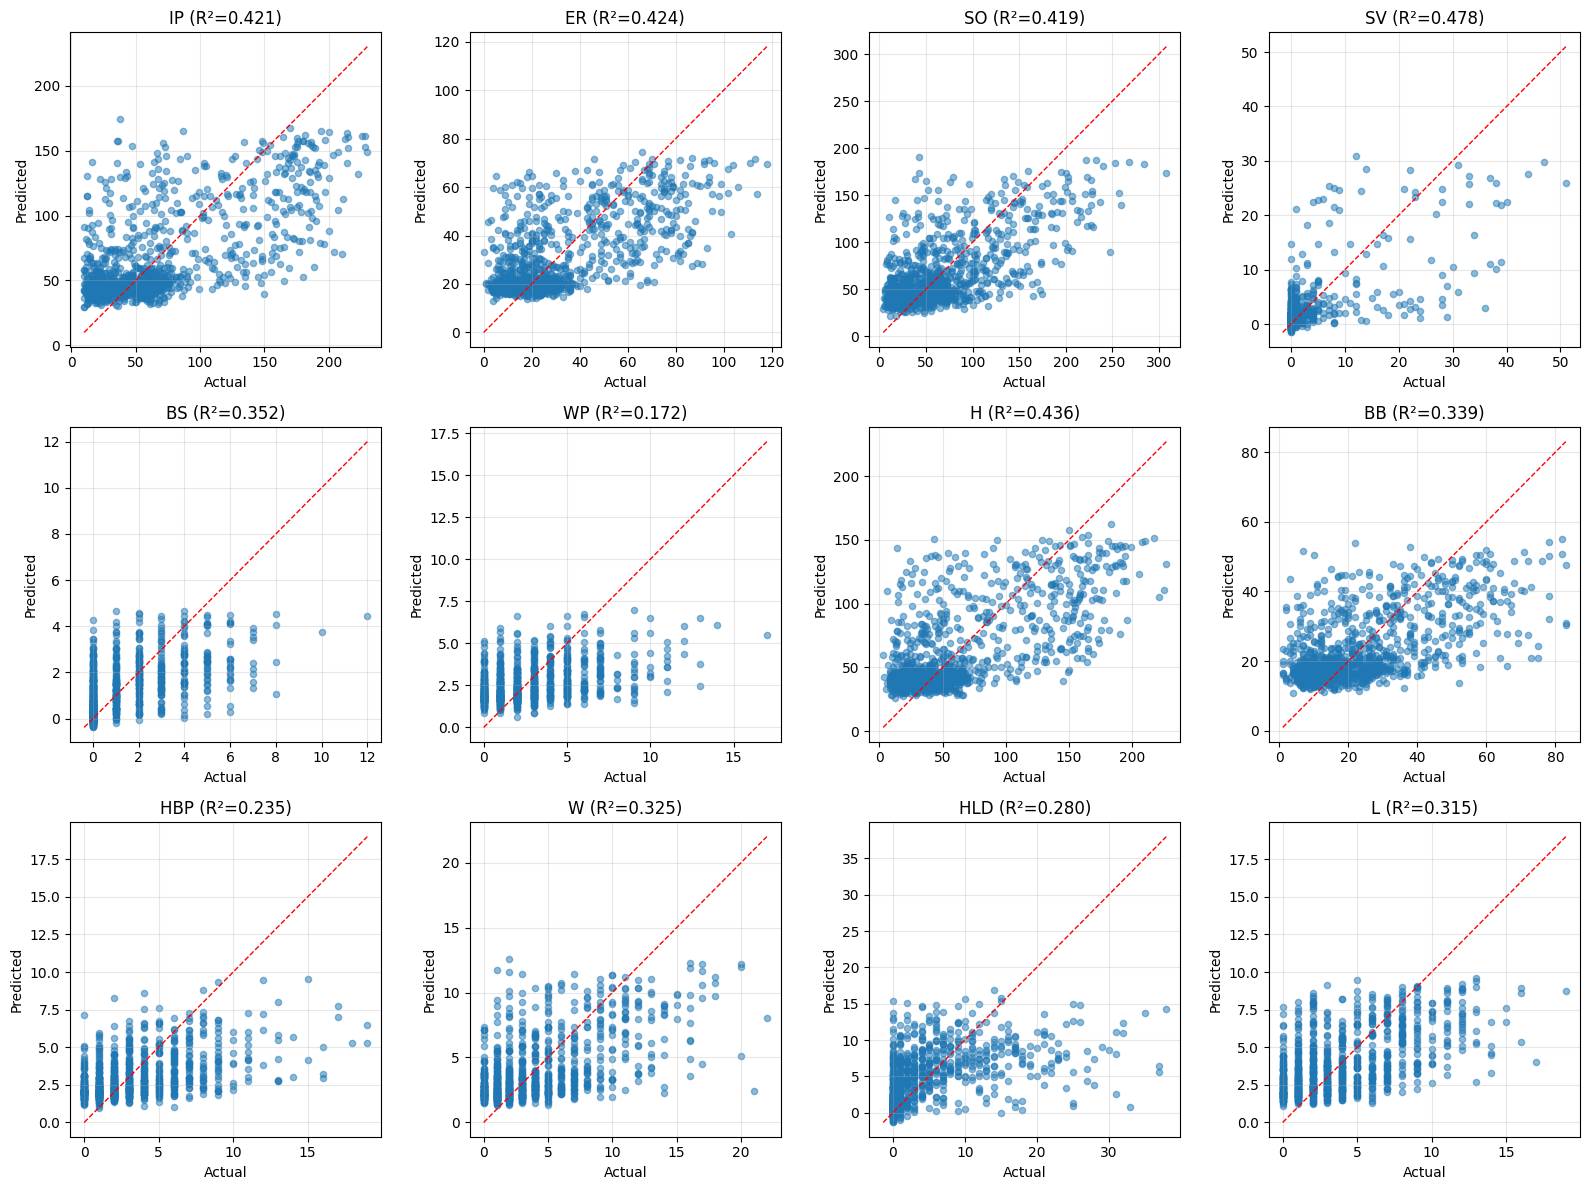

In [10]:
# Scatter plots for selected features
plot_features = list(score_map.keys())[:16]  # Fantasy-relevant features
n_plots = len(plot_features)
ncols = 4
nrows = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for idx, fname in enumerate(plot_features):
    i = features.index(fname)
    ax = axes[idx]
    ax.scatter(actuals_denorm[:, i], preds_denorm[:, i], alpha=0.5, s=20)
    lims = [
        min(actuals_denorm[:, i].min(), preds_denorm[:, i].min()),
        max(actuals_denorm[:, i].max(), preds_denorm[:, i].max()),
    ]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    r2 = per_feature_metrics[fname]['r2']
    ax.set_title(f'{fname} (R²={r2:.3f})')
    ax.grid(True, alpha=0.3)

for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save model weights
torch.save(best_model.state_dict(), os.path.join(RESULTS_DIR, 'best_model.pt'))

# Save scaler
with open(os.path.join(RESULTS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save metadata
metadata = {
    'model_type': 'MVT',
    'hyperparameters': {
        k: (float(v) if isinstance(v, (np.floating, float)) else
            int(v) if isinstance(v, (np.integer, int)) else v)
        for k, v in p.items()
    },
    'features': features,
    'score_map': score_map,
    'feature_stats': {k: list(v) for k, v in feature_stats.items()},
    'metrics': {
        'overall_mse': float(overall_mse),
        'overall_mae': float(overall_mae),
        'overall_r2': float(overall_r2),
    },
    'per_feature_metrics': per_feature_metrics,
}

with open(os.path.join(RESULTS_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved best model to {RESULTS_DIR}')
print(f'  best_model.pt, scaler.pkl, metadata.json')
print(f'  Overall — MSE: {overall_mse:.4f}, MAE: {overall_mae:.4f}, R²: {overall_r2:.4f}')

Saved best model to ./results/pitcher_model/mvt/
  best_model.pt, scaler.pkl, metadata.json
  Overall — MSE: 0.6647, MAE: 0.5888, R²: 0.3445
